# Amazon Data Analysis & Review Score Prediction

## Spark Setup

In [1]:
import pyspark
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib created a temporary cache directory at /scratch/bguo3/job_46984312/matplotlib-6qky0za4 because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
# Initializing our spark
"""
Formula == 
Executor instances = Total Cores - 1
Executor memory = (Total Memory - Driver Memory) / Executor Instances

Executor instances = 32 − 1 = 31
Executor memory = (128 − 2) / 31 ≈ 4.06GB → 4GB per executor

NOTE:
The execution size was the driving factor for this set based on previous experience \
working with social media analysis.
Given the 54GB size of the Amazon dataset, this configuration provides:

-High parallelism (31 concurrent tasks)
-Sufficient executor memory to reduce shuffle spill
-Balanced memory distribution to prevent executor OOM during aggregations

The 4GB executor size was chosen to provide adequate memory headroom for groupBy and \
aggregation operations without creating excessively large JVM heaps, \
which can increase garbage collection overhead.
"""

# spark= (
#     SparkSession.builder
#     .appName('amazon_set')
#     .config('spark.driver.memory', '2g')
#     .config('spark.executor.instances', '31')
#     .config('spark.executor.memory', '4g')
#     .config('spark.executor.cores', '1')
#     .getOrCreate()
# )

spark = (
    SparkSession.builder
    .appName('amazon_set')
    .config('spark.driver.memory', '4g')
    .config('spark.executor.instances', '7')
    .config('spark.executor.memory', '16g')
    .config('spark.executor.cores', '1')
    .getOrCreate()
)

In [3]:
import requests
import pandas as pd # RECALL we're going to use spark not pandas

# Get the active Spark Context and URL
sc = spark.sparkContext
url = f"{sc.uiWebUrl}/api/v1/applications/{sc.applicationId}/executors"

# Fetch the executor data from the API
response = requests.get(url)
executors = response.json()

# Format into a readable DataFrame
df = pd.DataFrame(executors)[['id', 'totalCores', 'maxMemory', 'activeTasks', 'isActive']]
df['maxMemory_GB'] = (df['maxMemory'] / (1024**3)).round(2)
df

,id,totalCores,maxMemory,activeTasks,isActive,maxMemory_GB
0,driver,8,2388236697,0,True,2.22


## Data Collection

In [4]:
import kagglehub
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType, StructField,
    StringType, IntegerType,
    DateType
)

# Download dataset (cached by kagglehub)
base_dir = kagglehub.dataset_download('cynthiarempel/amazon-us-customer-reviews-dataset')
print('Downloaded to:', base_dir)

# Schema (recommended)
schema = StructType([
    StructField('marketplace', StringType(), True),
    StructField('customer_id', StringType(), True),
    StructField('review_id', StringType(), True),
    StructField('product_id', StringType(), True),
    StructField('product_parent', StringType(), True),
    StructField('product_title', StringType(), True),
    StructField('product_category', StringType(), True),
    StructField('star_rating', IntegerType(), True),
    StructField('helpful_votes', IntegerType(), True),
    StructField('total_votes', IntegerType(), True),
    StructField('vine', StringType(), True),
    StructField('verified_purchase', StringType(), True),
    StructField('review_headline', StringType(), True),
    StructField('review_body', StringType(), True),
    StructField('review_date', DateType(), True),
])

pattern = f'file:{base_dir}/amazon_reviews_us_*_v*.tsv'

reviews_df = (
    spark.read
        .option('header', 'true')
        .option('sep', '\t')
        .schema(schema)
        .csv(pattern)
        .withColumn('source_file', F.input_file_name())
        .withColumn('category', F.regexp_extract('source_file', r'amazon_reviews_us_([^/]+?)_v', 1))
        .filter(F.col('category') != 'multilingual')
        .drop('source_file')
)

Downloaded to: /home/bguo3/.cache/kagglehub/datasets/cynthiarempel/amazon-us-customer-reviews-dataset/versions/9


In [5]:
# Check the Spark details
print('master:', spark.sparkContext.master)
print('partitions:', reviews_df.rdd.getNumPartitions())

master: local[*]
partitions: 384


In [6]:
# from pyspark import StorageLevel
# reviews_df = reviews_df.persist(StorageLevel.MEMORY_AND_DISK)

**Observations**: 
- We decided not cache the whole df yet because with total 40GB, with limited temporary storage, it blowed up.
- When cached SparkSQL Dataframe doing some tasks that involves occupying some space in memory, evicted the cached memory and spill to storage, unfortunately the temp storage also spill and crash the jupyter kernel
- Through using SLURM command, we maybe able to allocate more than 1 node, so hopefully that might helps, or caching the whole df might not even be a good idea starting from the beginning

## Exploratory Data Analysis

### Helper Functions

In [7]:
def row_memory_count(df):
    """
    Estimate row count and memory footprint of a Spark DataFrame.

    Args:
        df: Spark DataFrame to analyze

    Prints:
        - Total number of rows in the DataFrame
        - Estimated total memory usage in GB
    """

    # How many df rows do we have?
    row_counts = df.count()
    print(f"Total row counts: {row_counts} rows")
    
    # How much does df occupy in memory?
    sample_fraction = 0.001
    sample_size_in_bytes = (
        df
        .sample(fraction=sample_fraction)
        .toPandas()
        .memory_usage(deep=True)
        .sum()
    ) 
    total_size_in_gb = sample_size_in_bytes / (sample_fraction * (1024**3))
    print(f"Total estimated size: {total_size_in_gb:.2f} GB")

In [8]:
def plot_bar_chart(df, groupby_col, x_label, title, has_hue=True):
    """
    Plot a horizontal bar chart of the top N categories for a Spark DataFrame column.

    Args:
        df: Spark DataFrame
        groupby_col: Column name (string) to group by
        x_label: Label for the x-axis
        title: Plot title

    Notes:
        - Counts are annotated in millions (M) by default
    """
    
    # --- Data ---
    dist_pd = (
        df
        # Groupby + Agg(count) + Sort
        .groupBy(groupby_col)
        .count()
        .orderBy(F.desc('count'))
        .toPandas()
        .loc[lambda temp_df: temp_df[groupby_col].notna(), :]
        .assign(**{
            groupby_col: lambda df: df[groupby_col].astype('category')
        })
        .sort_values(by='count', ascending=False)
    )
    
    # --- Plot ---
    fig, ax = plt.subplots(figsize=(15, 6))
    sns.barplot(
        data=dist_pd,
        x='count',
        y=groupby_col,
        hue=groupby_col if has_hue else None,
        legend=False,
        palette='Blues_r' if has_hue else None,
        edgecolor='white',
        ax=ax,
        order=dist_pd[groupby_col].tolist(),
        hue_order=dist_pd[groupby_col].tolist()
    )
    # Edit text on categories
    for bar in ax.patches:
        w = bar.get_width()
        ax.text(
            w + 50_000, bar.get_y() + bar.get_height() / 2,
            f'{w/1_000_000:.2f}M',
            va='center', ha='left', fontsize=9, color='#333'
        )
    # Annotation
    ax.set_xlabel(x_label, fontsize=11)
    ax.set_title(
        title, 
        fontsize=14, 
        fontweight='bold', 
        pad=15
    )
    plt.show()

In [9]:
def plot_histogram(df, column, x_label, title, bins=50, kde=False):
    """
    Plot a histogram for a numerical column from a Spark DataFrame.

    Args:
        df: Spark DataFrame
        column: column name (string)
        bins: number of bins
        x_label: label for x-axis
        title: plot title
    """
    
    # --- Data ---
    dist_pd = (
        df
        .select(column)
        # Use 1% sample
        .sample(fraction=0.01, seed=42)
        .toPandas()
    )

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.histplot(
        dist_pd[column], 
        bins=bins, 
        kde=kde, 
        color='skyblue', 
        edgecolor='white', 
        ax=ax
    )
    ax.set_xlabel(
        column, 
        fontsize=11
    )
    ax.set_title(
        title, 
        fontsize=14, 
        fontweight='bold'
    )
    plt.show()

In [10]:
def plot_boxplot(df, column, x_label, title):
    """
    Plot a box plot for a numerical column from a Spark DataFrame.

    Args:
        df: Spark DataFrame
        column: column name (string) to plot
        x_label: label for the x-axis (optional)
        title: plot title (optional)
        sample_fraction: fraction of rows to sample (default 0.01 = 1%)
    """
    
    # --- Data ---
    dist_pd = (
        df
        .select(column)
        # Use 1% sample
        .sample(fraction=0.01, seed=42)
        .toPandas()
    )

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.boxplot(
        y=dist_pd[column], 
        color='lightblue', 
        ax=ax
    )
    ax.set_ylabel(
        x_label, 
        fontsize=11
    )
    ax.set_title(
        title, 
        fontsize=14, 
        fontweight='bold'
    )
    plt.show()

In [11]:
def some_speed_up_measurement():
    ...

### Overall Inspection

In [8]:
# We want to check if the df is successfully loaded

reviews_df.select('category', 'star_rating', 'product_id').show(10, truncate=False)

+--------+-----------+----------+
|category|star_rating|product_id|
+--------+-----------+----------+
|Apparel |4          |B01KL6O72Y|
|Apparel |5          |B01ID3ZS5W|
|Apparel |5          |B01I497BGY|
|Apparel |5          |B01HDXFZK6|
|Apparel |5          |B01G6MBEBY|
|Apparel |5          |B01FWRXN0Y|
|Apparel |5          |B01EXNH1HE|
|Apparel |4          |B01E7OL09O|
|Apparel |5          |B01DXHX81O|
|Apparel |3          |B01DDULIJK|
+--------+-----------+----------+
only showing top 10 rows



In [9]:
# Let's... see how big this data is!
# Row and memory count
row_memory_count(reviews_df)

Total row counts: 102899354 rows
Total estimated size: 117.77 GB


In [10]:
# Check the schema
reviews_df.printSchema()

root
 |-- marketplace: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- review_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- product_parent: string (nullable = true)
 |-- product_title: string (nullable = true)
 |-- product_category: string (nullable = true)
 |-- star_rating: integer (nullable = true)
 |-- helpful_votes: integer (nullable = true)
 |-- total_votes: integer (nullable = true)
 |-- vine: string (nullable = true)
 |-- verified_purchase: string (nullable = true)
 |-- review_headline: string (nullable = true)
 |-- review_body: string (nullable = true)
 |-- review_date: date (nullable = true)
 |-- category: string (nullable = false)



| Column | Description |
|---|---|
| **marketplace** | Country/region the review was posted on (e.g. US, UK) |
| **product_id** | Unique identifier for the product (ASIN on Amazon) |
| **product_parent** | Groups product variants (e.g. same book in hardcover/paperback) under one parent ID |
| **product_title** | Name/title of the product |
| **product_category** | Category the product belongs to (e.g. Wireless, Sports, Beauty) |
| **customer_id** | Unique identifier for the reviewer |
| **review_id** | Unique identifier for the review itself |
| **star_rating** | Rating given by the customer (1–5 stars) |
| **review_headline** | Short title/summary of the review |
| **review_body** | Full text of the review |
| **review_date** | Date the review was posted |
| **helpful_votes** | Number of people who found the review helpful |
| **total_votes** | Total number of people who voted on the review (helpful or not) |
| **vine** | Whether the reviewer is part of Amazon's Vine program (`Y`/`N`) |
| **verified_purchase** | Whether the reviewer actually bought the product on Amazon (`Y`/`N`) |
| **category** | Broader/redundant category label, possibly added during data processing |


In [12]:
# Check the summary statistics
reviews_df.describe().show()

+-------+-----------+--------------------+--------------+--------------------+-------------------+--------------------+--------------------+-----------------+------------------+-----------------+---------+-----------------+--------------------+--------------------+-----------+---------+
|summary|marketplace|         customer_id|     review_id|          product_id|     product_parent|       product_title|    product_category|      star_rating|     helpful_votes|      total_votes|     vine|verified_purchase|     review_headline|         review_body|review_date| category|
+-------+-----------+--------------------+--------------+--------------------+-------------------+--------------------+--------------------+-----------------+------------------+-----------------+---------+-----------------+--------------------+--------------------+-----------+---------+
|  count|  102899354|           102899354|     102899354|           102899354|          102899354|           102899354|           102897

| summary | marketplace | customer_id       | review_id        | product_id     | product_parent      | product_title            | product_category | star_rating   | helpful_votes | total_votes | vine  | verified_purchase | review_headline           | review_body              | review_date   | category |
|---------|------------|-----------------|-----------------|---------------|------------------|-----------------------|----------------|---------------|---------------|-------------|-------|-----------------|-------------------------|-------------------------|---------------|---------|
| count   | 102,899,354 | 102,899,354     | 102,899,354     | 102,899,354   | 102,899,354      | 102,899,354           | 102,897,602    | 102,897,561   | 102,897,561   | 102,897,561 | 102,897,561 | 102,897,561 | 102,897,322           | 102,887,488           | 102,891,724   | 102,899,354 |
| mean    | None       | 28,337,279.36    | None            | 1,425,824,476 | 500,333,796.44   | NaN                   | None           | 4.16          | 1.90          | 2.54        | None  | None            | NaN                     | Infinity                | None          | None    |
| stddev  | None       | 15,723,537       | None            | 1,936,226,418 | 288,790,891.53   | NaN                   | None           | 1.29          | 20.77         | 22.45       | None  | None            | NaN                     | NaN                     | None          | None    |
| min     | US         | 100,000          | R100007TERQ36I  | 0000000078    | 100,000,041      | Fine in Time           | 2002-08-07     | 1             | 0             | 0           | N     | N               | All was good :)          | I mad...                | 1995-06-24    | Apparel |
| max     | US         | 9,999,996        | RZZZZYOFYZ829   | BT00IU6O8K    | 999,999,945      | 🌴 Vacation On The Beach | "Red Spring Blossom Flowers with Yellow Bees..." | 5             | 47,524        | 48,362      | Y     | Y               | 🤹🏽‍♂️🎤Great product...  | 🛅🚑🚚🚏🚙🚈🚘🚈🚘🚏🚘🚙🚎🚎... | 2015-08-31    | Wireless |

### Missingness

In [13]:
# Check missing values per columns

(
    reviews_df
    # Project all columns
    .select([
        # Count all filtered values
        F.count(
            # When it meets these conditions
            F.when(
                # Define the condition
                F.col(c).isNotNull() | (F.col(c) != ""), 
                # Define the value to return
                c
            )
        )
        # Rename to 'c'
        .alias(c)
        # Iterate all columns
        for c in reviews_df.columns
    ])
    .show()
)

+-----------+-----------+---------+----------+--------------+-------------+----------------+-----------+-------------+-----------+---------+-----------------+---------------+-----------+-----------+---------+
|marketplace|customer_id|review_id|product_id|product_parent|product_title|product_category|star_rating|helpful_votes|total_votes|     vine|verified_purchase|review_headline|review_body|review_date| category|
+-----------+-----------+---------+----------+--------------+-------------+----------------+-----------+-------------+-----------+---------+-----------------+---------------+-----------+-----------+---------+
|  102899354|  102899354|102899354| 102899354|     102899354|    102899354|       102897602|  102897561|    102897561|  102897561|102897561|        102897561|      102897322|  102887488|  102891724|102899354|
+-----------+-----------+---------+----------+--------------+-------------+----------------+-----------+-------------+-----------+---------+-----------------+------

**Columns with Missing Values**
| Column            | Missing Count | Total Rows  | Missing % |
| ----------------- | ------------- | ----------- | --------- |
| product_category  | 1,752         | 102,899,354 | 0.0017%   |
| star_rating       | 1,793         | 102,899,354 | 0.0017%   |
| helpful_votes     | 1,793         | 102,899,354 | 0.0017%   |
| total_votes       | 1,793         | 102,899,354 | 0.0017%   |
| vine              | 1,793         | 102,899,354 | 0.0017%   |
| verified_purchase | 1,793         | 102,899,354 | 0.0017%   |
| review_headline   | 11,866        | 102,899,354 | 0.0115%   |
| review_date       | 7,630         | 102,899,354 | 0.0074%   |

**Observations**: 

Missingness is below 0.02% across all features. Given the extremely large sample size (~10^8), listwise deletion for the target and simple deterministic imputation for predictors will not affect distributional properties or predictive performance. Therefore, complex probabilistic imputation is not necessary. Therefore, I decided to perform list-wise deletion and simple deterministic imputation (per requirement) to deal with missingness

### Feature Distribution

In [ ]:
# Product category distribution

plot_bar_chart(
    reviews_df, 
    'category', 
    'Number of Reviews',
    'Product Categories by Review Count'
)

plot_bar_chart(
    reviews_df, 
    'product_category', 
    'Number of Reviews',
    'Product Categories by Review Count'
)


# Let's play with the data. What are our most popular products?
top_categories = (
    reviews_df
    .groupBy('product_category')
    .agg(F.count('*').alias('review_count'))
    .orderBy(F.desc('review_count'))
    .limit(10)
)
top_categories.show(truncate=False)

**Observations**: Categories are highly unbalanced, there are a lot of technology/electronic-related categories, but they both have the highest and lowest count. It would be an issue if the prediction is about category classification.

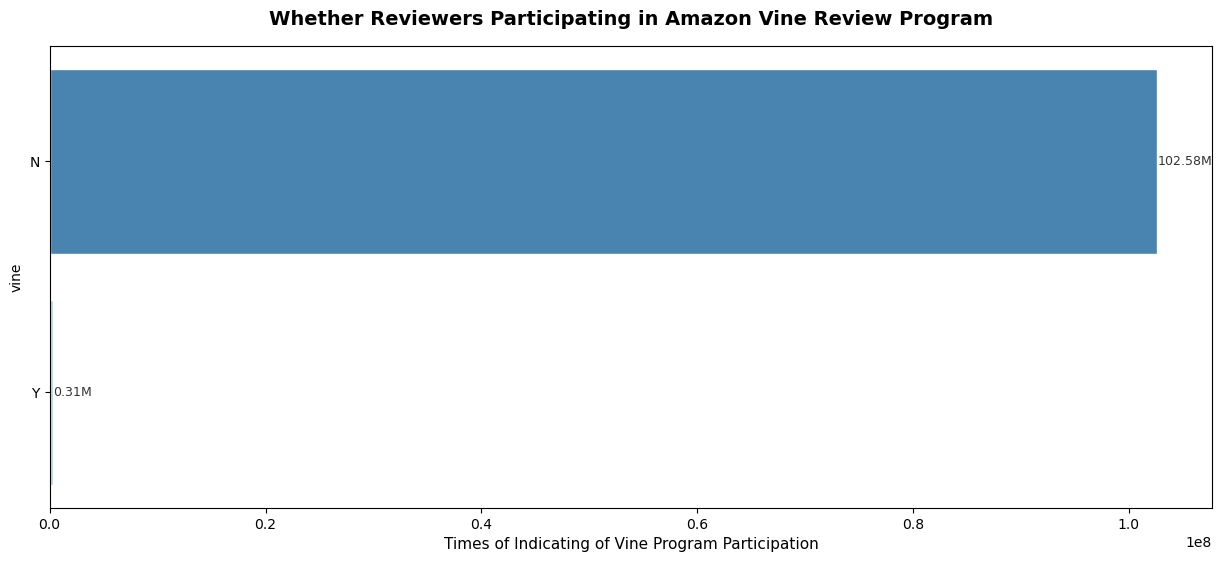

In [34]:
# Vine Distribution

plot_bar_chart(
    reviews_df, 
    'vine', 
    'Times of Indicating of Vine Program Participation', 
    'Whether Reviewers Participating in Amazon Vine Review Program'
)

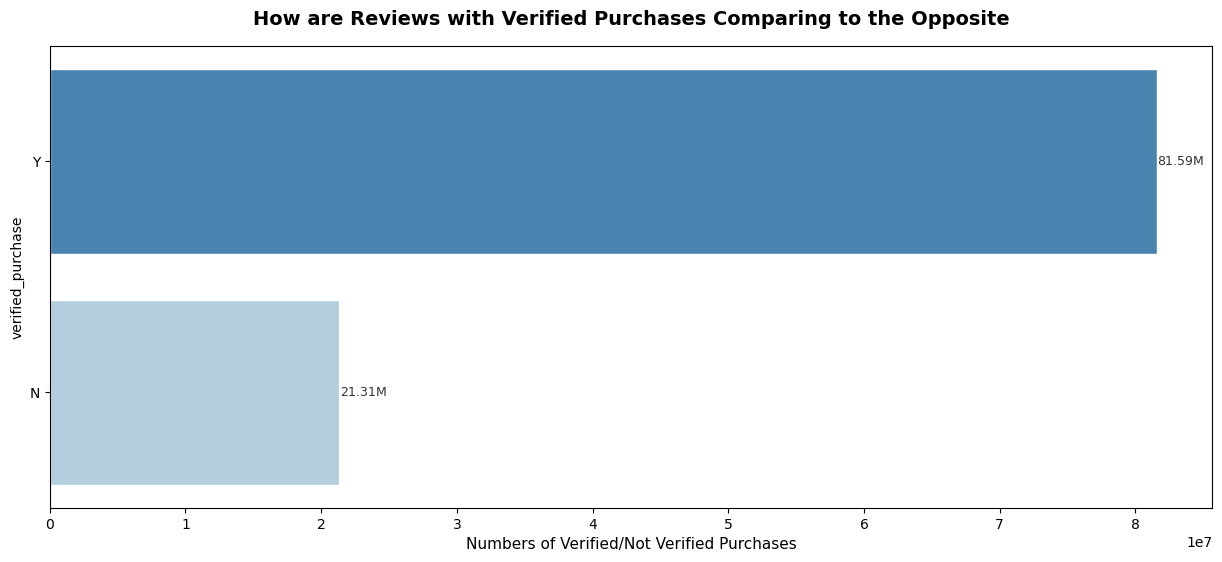

In [35]:
# Verified Purchase Distribution

plot_bar_chart(
    reviews_df, 
    'verified_purchase', 
    'Numbers of Verified/Not Verified Purchases', 
    'How are Reviews with Verified Purchases Comparing to the Opposite'
)

**Observations**: The class for Vine is extremely imbalance, and verified_purchases it's better but 'Y' has 60% more data than 'N'

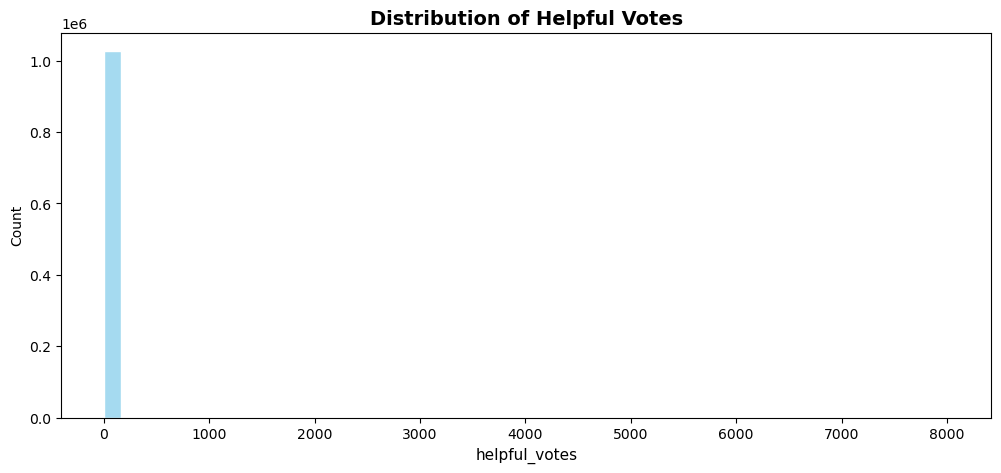

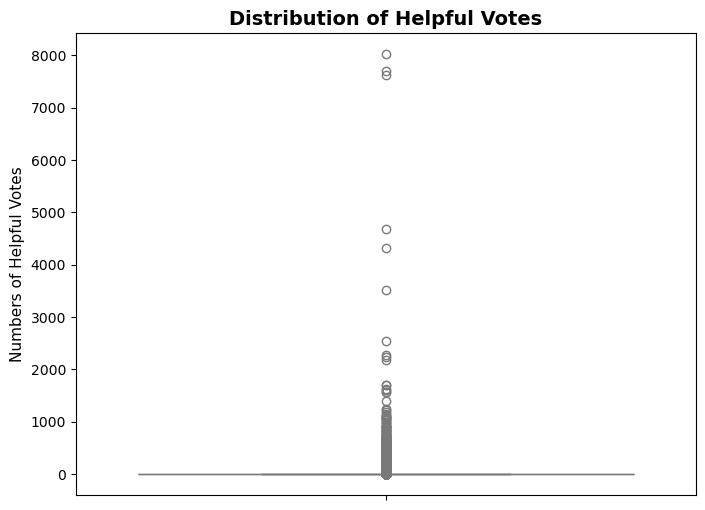

In [36]:
# Helpful Votes Distribution

plot_histogram(
    reviews_df, 
    'helpful_votes', 
    'Numbers of Helpful Votes', 
    'Distribution of Helpful Votes'
)

plot_boxplot(
    reviews_df, 
    'helpful_votes', 
    'Numbers of Helpful Votes', 
    'Distribution of Helpful Votes'
)

**Observations**: Helpful votes mostly inclines to 0, while having extereme outlier value such as 8000. It would be interesting to check the review with outlier values more than 2000. So this columns has a extremely right skewed distribution

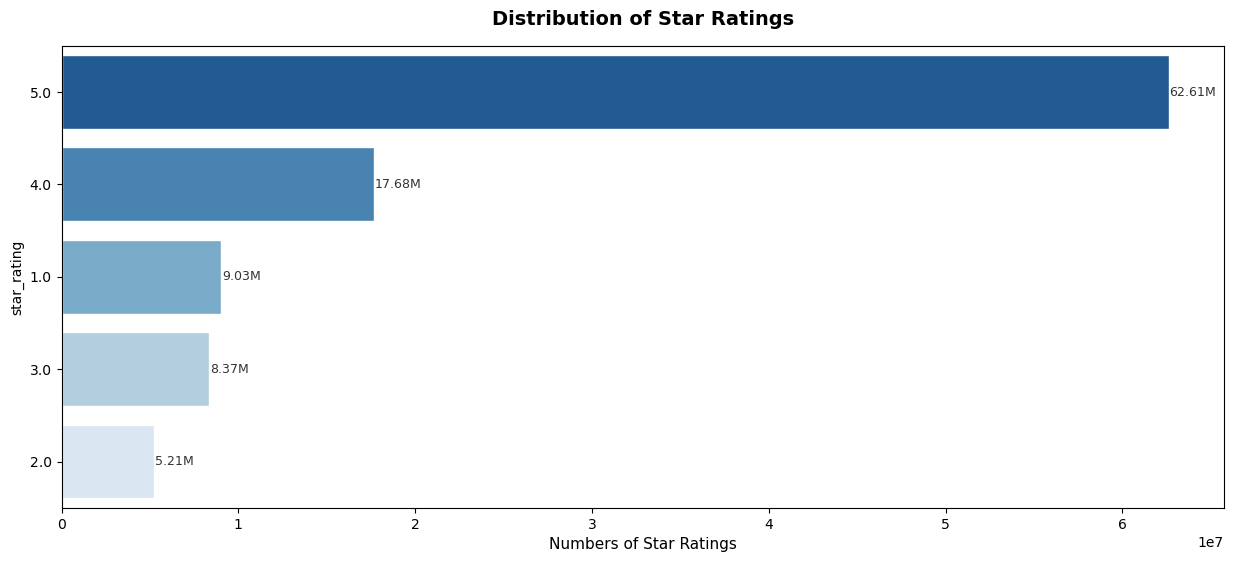

In [37]:
# Rating Distribution

plot_bar_chart(
    reviews_df, 
    'star_rating', 
    'Numbers of Star Ratings', 
    'Distribution of Star Ratings'
)

### Sport Analysis

In [18]:
# Let's focus on a sports-specific data frame for plotting 
# since sports have the lowest review counts among the most popular categories

# We'll scale this up for our own needs with all the data in the future
sports_df = (
    reviews_df
    .filter(F.lower(F.col('product_category')) == 'sports')
)

# materialize cache (important)
sports_df.cache()

# Row and memory counts for sports_df
row_memory_count(sports_df)

Total row counts: 4849563 rows
Total estimated size: 5.23 GB


**Observations**: 
- We can see that sports_df occupied about 5 GB of data, which is why setting the memory of 4GB per executor does not work
- We already know that the review_df has (total row: 102899354, total size: 118.75 GB), since sports_df row counts is around 4% of the review_df row counts, so it's reasonable to directly estimate that sports_df memory is around 4% of review_df's

In [19]:
# How about if we check for the unique sports products by product_id

distinct_sports_products = (
    sports_df
    .select('product_id')
    .distinct()
    .count()
)
print(f'Distinct Sports products: {distinct_sports_products}')

Distinct Sports products: 1046129


+----------+-----+
|product_id|count|
+----------+-----+
|B001HBHNHE|7405 |
|7245456313|3693 |
|B00FX0S4DC|3051 |
|B000UVVX28|3006 |
|B002QZ1RS6|2922 |
|B003TJH3LI|2823 |
|B005M1P85O|2786 |
|B001EJMS6K|2560 |
|B00178CS4K|2299 |
|B00B1N0R6C|2278 |
+----------+-----+



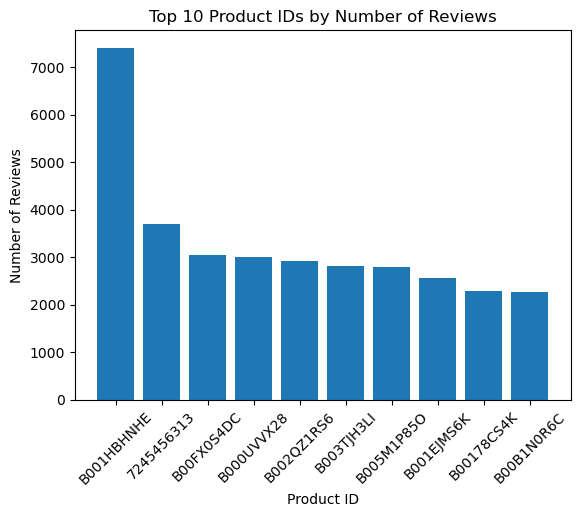

In [20]:
# --- Data ---
top10_products = (
    sports_df
    .groupBy('product_id')
    .count()
    .orderBy(F.desc('count'))
    .limit(10)
)
top10_products.show(truncate=False)
top10_pd = top10_products.toPandas()

# --- Plot ----
plt.figure()
plt.bar(top10_pd['product_id'], top10_pd['count'])
plt.xticks(rotation = 45)
plt.xlabel('Product ID')
plt.ylabel('Number of Reviews')
plt.title('Top 10 Product IDs by Number of Reviews')
plt.show()

**Observation**: The result shows that many products receive at least one review, so unique product count < total row count

In [21]:
# Discretize star rating 
# (As it was defined to be an integer, this just ensures it works as expected)

sports_df_clean = (
    sports_df
    .withColumn("star_rating_int", F.expr("try_cast(star_rating as int)"))
    .filter(F.col("star_rating_int").isNotNull())
)

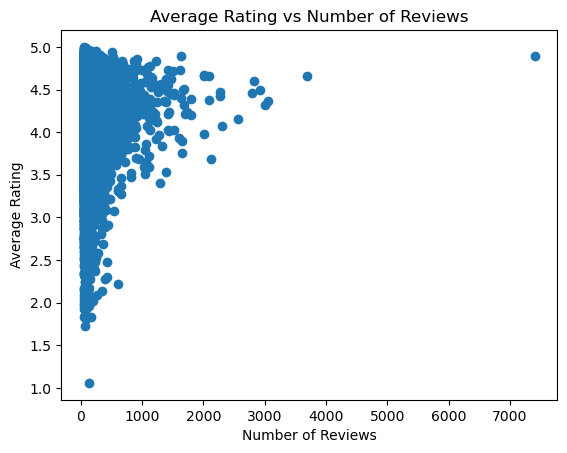

In [23]:
# We want to see if number of review correlates with average ratings

# --- Data ---
average_rating_df = (
    sports_df_clean  
    .groupBy("product_id")
    .agg(
        F.avg("star_rating_int").alias("avg_rating"),
        F.count("*").alias("num_reviews")
    )
     # avoid tiny sample noise
    .filter(F.col("num_reviews") > 50) 
)
average_rating_pd = average_rating_df.toPandas()

# --- Plot ---
plt.figure()
plt.scatter(average_rating_pd['num_reviews'], average_rating_pd['avg_rating'])
plt.xlabel('Number of Reviews')
plt.ylabel('Average Rating')
plt.title('Average Rating vs Number of Reviews')
plt.show()

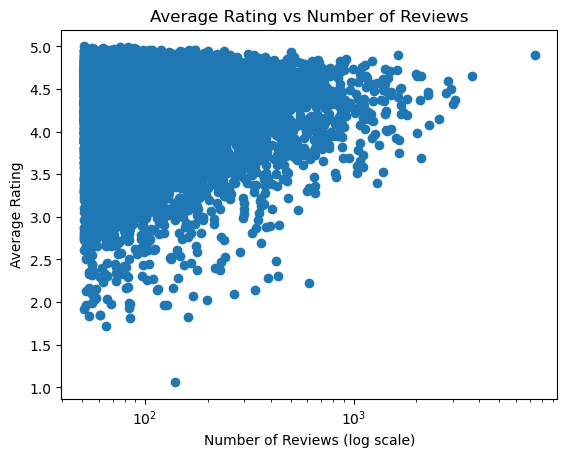

In [24]:
# We want to see it in log plot

plt.figure()
plt.scatter(average_rating_pd['num_reviews'], average_rating_pd['avg_rating'])
plt.xscale('log')
plt.xlabel('Number of Reviews (log scale)')
plt.ylabel('Average Rating')
plt.title('Average Rating vs Number of Reviews')
plt.show()

## Data Preprocessing 

In [12]:
# Import ML related libraries here

from pyspark.ml.feature import Imputer

### Relevant Features for ML (Feature Selection)

| Column            | Status | Justification / Impact                                                                                              |
| ----------------- | ------ | ------------------------------------------------------------------------------------------------------------------- |
| marketplace       | ✅      | Restrict to U.S. marketplace for English-language consistency; won’t add predictive value after filtering           |
| customer_id       | ❌      | High cardinality; no generalizable predictive structure; could allow aggregation of user behavior but not essential |
| review_id         | ❌      | Unique key only; no predictive value                                                                                |
| product_id        | ✅      | Important for grouping reviews; enables aggregation to detect product-specific rating tendencies                    |
| product_parent    | ❌    | We can just rely on product_id                      |
| product_title     | ✅      | Useful for sanity-checking product_id; can be tokenized for NLP features if needed                                  |
| product_category  | ✅      | Useful for one-hot encoding; different categories may have varying rating distributions                             |
| star_rating       | ✅✅✅   | Target variable; ranking matters but intervals may not be perfectly aligned                                         |
| helpful_votes     | ✅      | Indicates perceived usefulness; can combine with total_votes to create helpfulness ratio                            |
| total_votes       | ✅      | Indicates overall engagement; can combine with helpful_votes to measure helpfulness ratio                           |
| vine              | ❌    | Binary; Amazon Vine reviews may indicate incentivized reviews, extreme class imbalance issues                                       |
| verified_purchase | ✅ / ❌      | Affects credibility; verified reviews may correlate with stronger sentiment, obvious class imbalance                                         |
| review_headline   | ✅      | Useful for NLP; headlines often contain strong sentiment signals                                                 |                                                |
| review_body       | ✅      | Primary feature for NLP: tokenization, sentiment analysis, review length, vocabulary frequency                      |
| review_date       | ❌      | Despite enabling seasonality/trend analysis; can be transformed into month, year, or holiday-period indicators, we will need time-awared version of train/test split, which is not available in Spark MLlib            |


In [13]:
# Discard features with strictly ❌ sign

ml_df = reviews_df.select([
    feat 
    for feat in reviews_df.columns 
    if feat not in [
    'customer_id',
    'review_id',
    'product_parent',
    'vine',
    'review_date'
    ]
])

### Handle Missing Values (Row Filtering & Value Imputation)

In [14]:
# Remove the missing rows for star rating columns
# We don't want to impute any artificial values 

# Perform list-wise deletion
from functools import reduce
ml_df = ml_df.filter(
    reduce(
        # Define action
        lambda x, y: 
        x & y,
        # Define a condition 
        [F.col('star_rating').isNotNull() | (F.col('star_rating') != "")]
     )
)

row_memory_count(ml_df)

Total row counts: 102897561 rows
Total estimated size: 87.20 GB


In [15]:
# Impute the missing rows for features with specific value 

ml_df = ml_df.fillna({
    'product_category': 'Unknown',
    "verified_purchase": "Unknown",
    "review_headline": "",
    'helpful_votes': 0,
    'total_votes': 0
})

In [16]:
# Check for missing values
(
    ml_df
    # Project all columns
    .select([
        # Count all filtered values
        F.count(
            # When it meets these conditions
            F.when( F.col(c).isNull(), c)
        )
        # Rename to 'c'
        .alias(c)
        # Iterate all columns
        for c in ml_df.columns
    ])
    .show()
)

+-----------+----------+-------------+----------------+-----------+-------------+-----------+-----------------+---------------+-----------+--------+
|marketplace|product_id|product_title|product_category|star_rating|helpful_votes|total_votes|verified_purchase|review_headline|review_body|category|
+-----------+----------+-------------+----------------+-----------+-------------+-----------+-----------------+---------------+-----------+--------+
|          0|         0|            0|               0|          0|            0|          0|                0|              0|      10073|       0|
+-----------+----------+-------------+----------------+-----------+-------------+-----------+-----------------+---------------+-----------+--------+



### Handle Unbalanced Classes (Feature Engineering)

In [19]:
# Compute the weight for star_ratings

# Gather total & class count
weight_total_count = ml_df.count()
weight_class_counts = (
    ml_df
    .groupBy('star_rating')
    .count()
    .collect()
)
# Get weights as dictionary
weights_dict = {
    class_row['star_rating'] : class_row['count']/ weight_total_count
    for class_row in weight_class_counts
}
# Change it to Spark column type, for later use
weights_spark = [
    F.lit(x)
    for kv in weights_dict.items()
    for x in kv
]
# Create a new feature with weights
ml_df = (
    ml_df.withColumn(
        'class_weight',
        F.create_map(weights_spark)[F.col('star_rating')]
    )
)

ml_df.printSchema()

root
 |-- marketplace: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- product_title: string (nullable = true)
 |-- product_category: string (nullable = false)
 |-- star_rating: integer (nullable = true)
 |-- helpful_votes: integer (nullable = false)
 |-- total_votes: integer (nullable = false)
 |-- verified_purchase: string (nullable = false)
 |-- review_headline: string (nullable = false)
 |-- review_body: string (nullable = true)
 |-- category: string (nullable = false)
 |-- class_weight: double (nullable = true)



### Handle Skew Distribution (Feature Normalization)

### Vectorize Category Features (Feature Encoding)

### Vectorize Text Features (Feature Encoding)